# 01 — Signal processing baseline

**Dataset:** `drive_day_2026`

**Question:** Does telemetry contain reviewable recurring periods?

Source timestamps retained; elapsed time comes from recorded timestamp column. Motor and electrical channels drive recurrence analysis. Requested steering, wheel, and oil signals are absent. Recurrence candidates remain unverified.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.data import load_recording, select_informative_channels
from lap_estimation.integration import benchmark_interpolation, build_integrated_features
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "drive_day_2026"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,07173121b1534f1eadb8b127005d4eff70872388074c2b...,21.9,moving_candidate,False,recorded_time_column,train
1,1a8433bf1168531d6f7c2deb5c37b27de5ddf1d9f65316...,21.9,moving_candidate,False,recorded_time_column,train
2,1cca7c275163fc193899535ebb0c13f26676e8568d3c8a...,37.9,moving_candidate,False,recorded_time_column,train
3,200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c7...,57.8,moving_candidate,False,recorded_time_column,train
4,25aa01e1dcbaea32c062e01b0f782c938c34163fc58af1...,73.7,moving_candidate,False,recorded_time_column,train
5,2f775054c4e7bb342cf49e0ee66406e82353c274c103fc...,25.9,moving_candidate,False,recorded_time_column,train
6,382db1f8ede73f956341d7b461790125339762ec9d7cc9...,57.8,stationary_candidate,True,recorded_time_column,train
7,4c8d0190b666e26315ce16c862ca2e968d576e14537487...,21.9,moving_candidate,False,recorded_time_column,train
8,554af5ad576c1c1d069356649e3bd1e2699a5801f6a0fa...,17.9,stationary_candidate,True,recorded_time_column,train
9,564a12f3d813c10242613a907d2b4981e7296739ba9a56...,57.8,stationary_candidate,True,recorded_time_column,train


In [2]:
overview = pd.Series(
    {
        "recordings": len(manifest),
        "source_paths": int(manifest["alias_count"].sum()),
        "duration_min": manifest["duration_s"].sum() / 60.0,
        "native_sample_rate_hz": dataset.native_sample_rate_hz,
        "control_candidates": int(manifest["control_candidate"].sum()),
        "clock_provenance": dataset.clock_provenance,
    },
    name="value",
)
overview.to_frame()

,value
recordings,21
source_paths,26
duration_min,19.82
native_sample_rate_hz,10.0
control_candidates,5
clock_provenance,recorded_time_column


In [3]:
result = run_experiment("01_signal_processing", ROOT, dataset_key=DATASET_KEY)
profile = pd.read_csv(result.output_dir / "data_profile.csv")
coverage = pd.read_csv(result.output_dir / "sensor_coverage.csv")
candidates = pd.read_csv(result.output_dir / "periodicity_candidates.csv")
smoothing = pd.read_csv(result.output_dir / "smoothing_sensitivity.csv")
display(result.metrics)
display(result.predictions.sort_values("score", ascending=False))
display(profile.sort_values("duration_s", ascending=False))

,task,split,metric,value,sample_count,reference_source
0,recurrence,all,non_control_recording_coverage,0.562500,16,none
1,recurrence,all,non_control_review_candidate_rate,0.444444,9,unverified_threshold
2,recurrence,all,control_candidate_detection_rate,0.250000,4,motor_rpm_threshold
3,data_quality,all,duplicate_alias_count,5.000000,26,sha256


,recording_id,segment_id,start_s,end_s,prediction_kind,score,predicted_period_s,label_status
0,6faa006353747cbeb4e6d2e90954728110cb94fabfcd41...,period_candidate_1,0.0,89.6,recurrence_period,0.774297,42.5,provisional_unverified
1,e57d3de89d6f2a3165aa05beee7b611f60923e09025433...,period_candidate_1,0.0,57.8,recurrence_period,0.284115,23.3,provisional_unverified
2,5e9e04831922d971561f6ffb53b2c77744d905cca01dcc...,period_candidate_1,0.0,41.8,recurrence_period,0.273548,19.9,provisional_unverified
3,667a6e15a4394db30d7cce7a4db319041453bfa306b566...,period_candidate_1,0.0,229.1,recurrence_period,0.257325,105.0,provisional_unverified
4,953f71ef131b4c5ce7211560abcbafbfe0079e72cf2190...,period_candidate_1,0.0,89.6,recurrence_period,0.256684,37.1,provisional_unverified
5,382db1f8ede73f956341d7b461790125339762ec9d7cc9...,period_candidate_1,0.0,57.8,recurrence_period,0.235088,28.3,provisional_unverified
6,629d7d57091b71c5c0c2c6f42218702e454b4ae60e2063...,period_candidate_1,0.0,85.7,recurrence_period,0.204647,42.3,provisional_unverified
7,c5c639ca1fa3038e565a432a960cb53f6ce533ad9612d2...,period_candidate_1,0.0,33.8,recurrence_period,0.176851,16.7,provisional_unverified
8,6939b3836a088e9113eb3bffcf362bed963a71bbd9012e...,period_candidate_1,0.0,65.7,recurrence_period,0.165367,17.3,provisional_unverified
9,564a12f3d813c10242613a907d2b4981e7296739ba9a56...,period_candidate_1,0.0,57.8,recurrence_period,0.108717,28.4,provisional_unverified


,recording_id,alias_count,driver_labels,driver_ambiguous,row_count,duration_s,declared_duration_s,sampled_elapsed_span_s,median_interval_s,max_gap_s,dynamic_numeric_count,max_abs_rpm,motion_variation_score,motion_status,motion_status_source,control_candidate,clock_provenance,vertical_accel_offset_flag,split
0,667a6e15a4394db30d7cce7a4db319041453bfa306b566...,1,"[""Tristan""]",False,2292,229.1,NaN,229.1,0.1,0.1,31,3326.0,90.615,moving_candidate,motor_rpm_threshold,False,recorded_time_column,False,train
1,953f71ef131b4c5ce7211560abcbafbfe0079e72cf2190...,1,"[""Yianni""]",False,897,89.6,NaN,89.6,0.1,0.1,10,0.0,0.000,stationary_candidate,motor_rpm_threshold,True,recorded_time_column,False,validation
2,6faa006353747cbeb4e6d2e90954728110cb94fabfcd41...,2,"[""Tristan"", ""Yianni""]",True,897,89.6,NaN,89.6,0.1,0.1,27,3136.5,73.580,moving_candidate,motor_rpm_threshold,False,recorded_time_column,False,validation
3,629d7d57091b71c5c0c2c6f42218702e454b4ae60e2063...,2,"[""Tristan"", ""Yianni""]",True,858,85.7,NaN,85.7,0.1,0.1,26,1995.6,35.865,moving_candidate,motor_rpm_threshold,False,recorded_time_column,False,train
4,25aa01e1dcbaea32c062e01b0f782c938c34163fc58af1...,2,"[""Tristan"", ""Yianni""]",True,738,73.7,NaN,73.7,0.1,0.1,29,3267.1,68.755,moving_candidate,motor_rpm_threshold,False,recorded_time_column,False,train
5,6939b3836a088e9113eb3bffcf362bed963a71bbd9012e...,1,"[""Ryan""]",False,658,65.7,NaN,65.7,0.1,0.1,27,2357.0,72.475,moving_candidate,motor_rpm_threshold,False,recorded_time_column,False,validation
6,e57d3de89d6f2a3165aa05beee7b611f60923e09025433...,1,"[""Tristan""]",False,579,57.8,NaN,57.8,0.1,0.1,22,2438.9,79.720,moving_candidate,motor_rpm_threshold,False,recorded_time_column,False,test
7,382db1f8ede73f956341d7b461790125339762ec9d7cc9...,1,"[""Yianni""]",False,579,57.8,NaN,57.8,0.1,0.1,11,0.0,0.000,stationary_candidate,motor_rpm_threshold,True,recorded_time_column,False,train
8,200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c7...,1,"[""Emiliano""]",False,579,57.8,NaN,57.8,0.1,0.1,20,2440.2,48.340,moving_candidate,motor_rpm_threshold,False,recorded_time_column,False,train
9,564a12f3d813c10242613a907d2b4981e7296739ba9a56...,2,"[""Tristan"", ""Yianni""]",True,579,57.8,NaN,57.8,0.1,0.1,18,1.2,0.000,stationary_candidate,motor_rpm_threshold,True,recorded_time_column,False,train


## Recording inventory and sensor availability

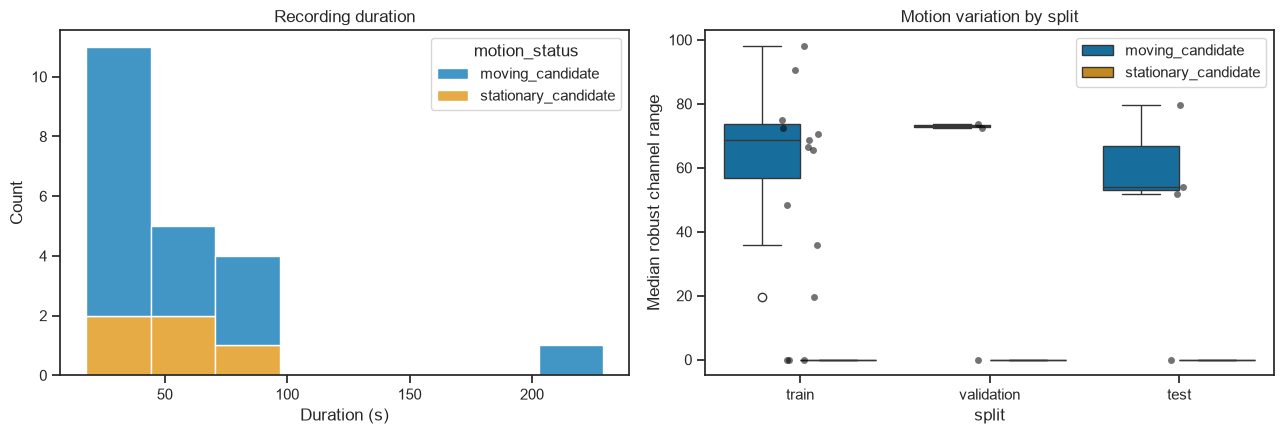

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=profile, x="duration_s", hue="motion_status", multiple="stack", ax=axes[0])
axes[0].set(title="Recording duration", xlabel="Duration (s)")
sns.boxplot(data=profile, x="split", y="motion_variation_score", hue="motion_status", ax=axes[1])
sns.stripplot(data=profile, x="split", y="motion_variation_score", color="black", alpha=0.55, ax=axes[1])
axes[1].set(title="Motion variation by split", ylabel="Median robust channel range")
fig.tight_layout()

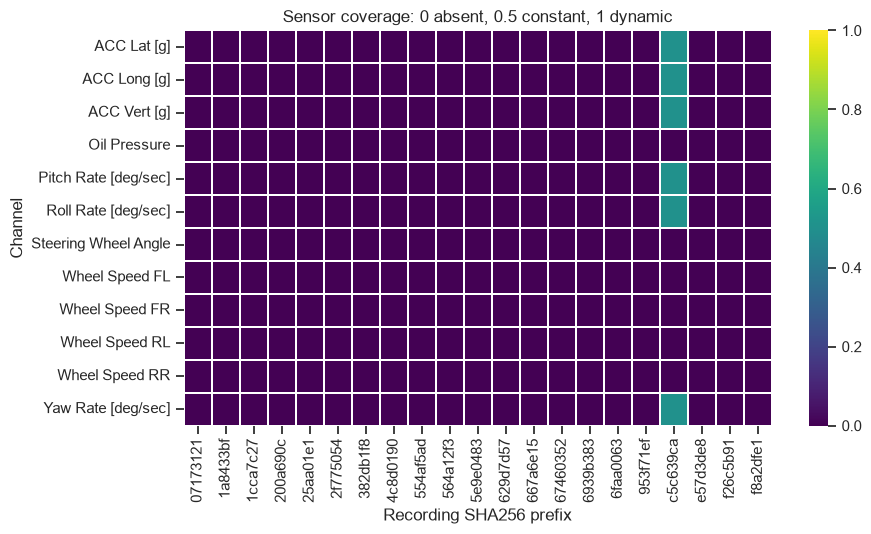

In [5]:
coverage_matrix = coverage.assign(recording=coverage["recording_id"].str[:8], available=coverage["state"].map({"absent": 0, "constant": 0.5, "dynamic": 1.0})).pivot(index="channel", columns="recording", values="available")
fig, ax = plt.subplots(figsize=(max(9, coverage_matrix.shape[1] * 0.45), 5.5))
sns.heatmap(coverage_matrix, cmap="viridis", vmin=0, vmax=1, linewidths=0.2, ax=ax)
ax.set(title="Sensor coverage: 0 absent, 0.5 constant, 1 dynamic", xlabel="Recording SHA256 prefix", ylabel="Channel")
fig.tight_layout()

## Representative native sensor traces

Text(0.5, 1.01, 'drive_day_2026: longest non-control recordings')

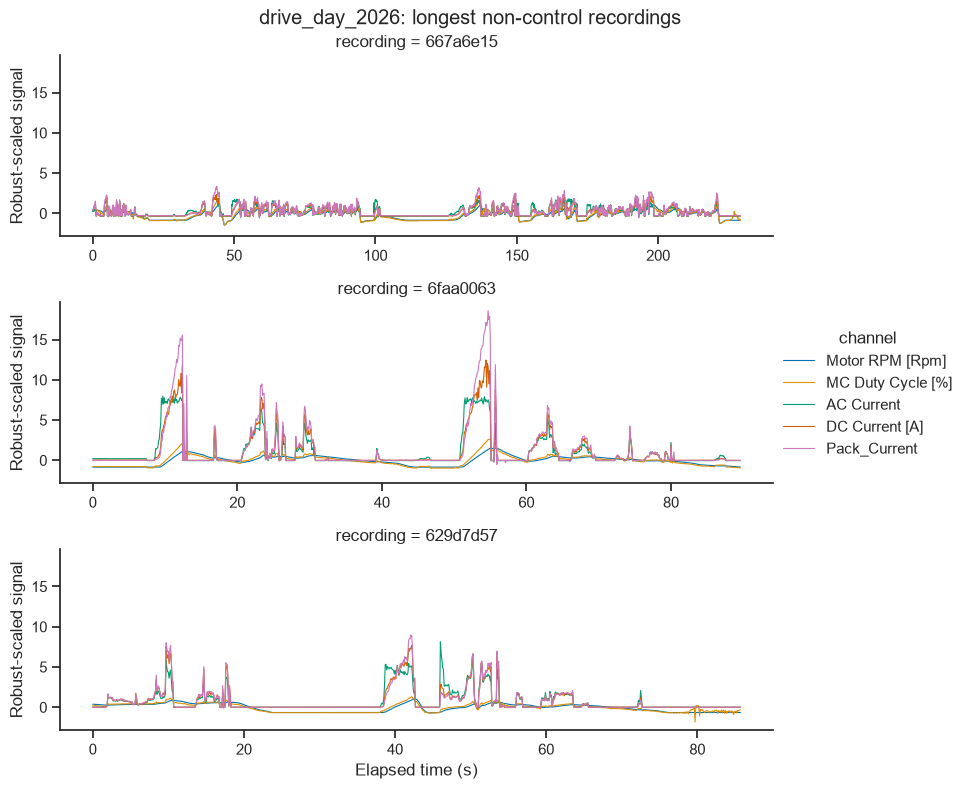

In [6]:
trace_rows = []
selected_records = manifest.loc[~manifest["control_candidate"]].nlargest(3, "duration_s")
for record in selected_records.itertuples(index=False):
    frame = load_recording(record.primary_path, dataset)
    channels = select_informative_channels(frame, dataset.analysis_channels)
    step = max(1, len(frame) // 1500)
    sampled = frame.iloc[::step]
    for channel in channels:
        values = pd.to_numeric(sampled[channel], errors="coerce")
        scale = values.quantile(0.75) - values.quantile(0.25)
        scaled = (values - values.median()) / (scale if scale > 1e-12 else 1.0)
        trace_rows.append(pd.DataFrame({"elapsed_s": sampled["elapsed_s"], "scaled_value": scaled, "channel": channel, "recording": record.recording_id[:8]}))
trace_data = pd.concat(trace_rows, ignore_index=True)
grid = sns.relplot(data=trace_data, x="elapsed_s", y="scaled_value", hue="channel", col="recording", col_wrap=1, kind="line", height=2.6, aspect=3.1, linewidth=0.8, facet_kws={"sharex": False})
grid.set_axis_labels("Elapsed time (s)", "Robust-scaled signal")
grid.figure.suptitle(f"{DATASET_KEY}: longest non-control recordings", y=1.01)

## Recurrence candidates and smoothing sensitivity

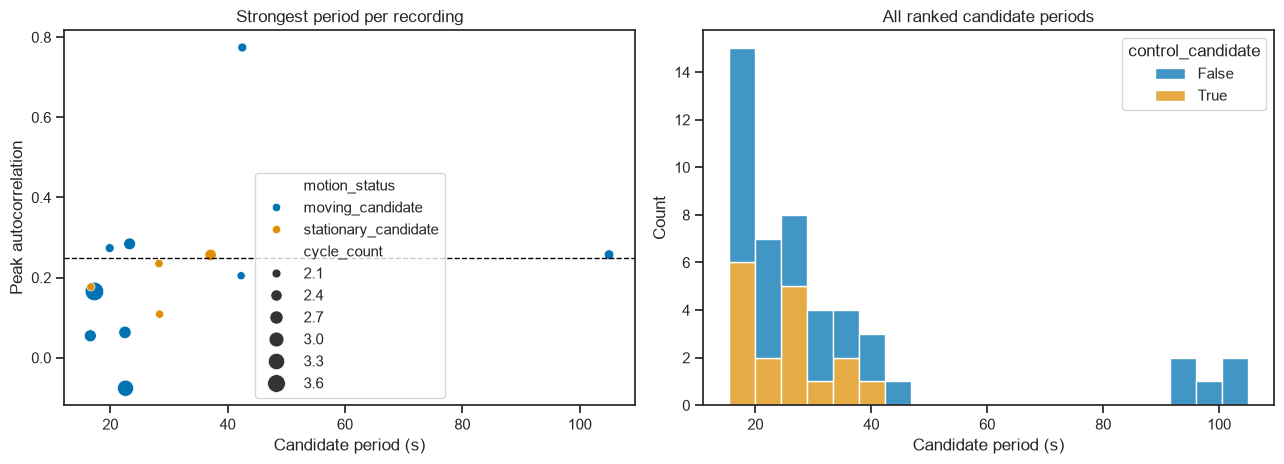

In [7]:
top = candidates.loc[candidates["rank"] == 1].merge(manifest[["recording_id", "motion_status"]], on="recording_id", how="left")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.scatterplot(data=top, x="lag_s", y="correlation", hue="motion_status", size="cycle_count", sizes=(35, 180), ax=axes[0])
axes[0].axhline(0.25, color="black", linestyle="--", linewidth=1)
axes[0].set(title="Strongest period per recording", xlabel="Candidate period (s)", ylabel="Peak autocorrelation")
sns.histplot(data=candidates, x="lag_s", hue="control_candidate", multiple="stack", bins=20, ax=axes[1])
axes[1].set(title="All ranked candidate periods", xlabel="Candidate period (s)")
fig.tight_layout()

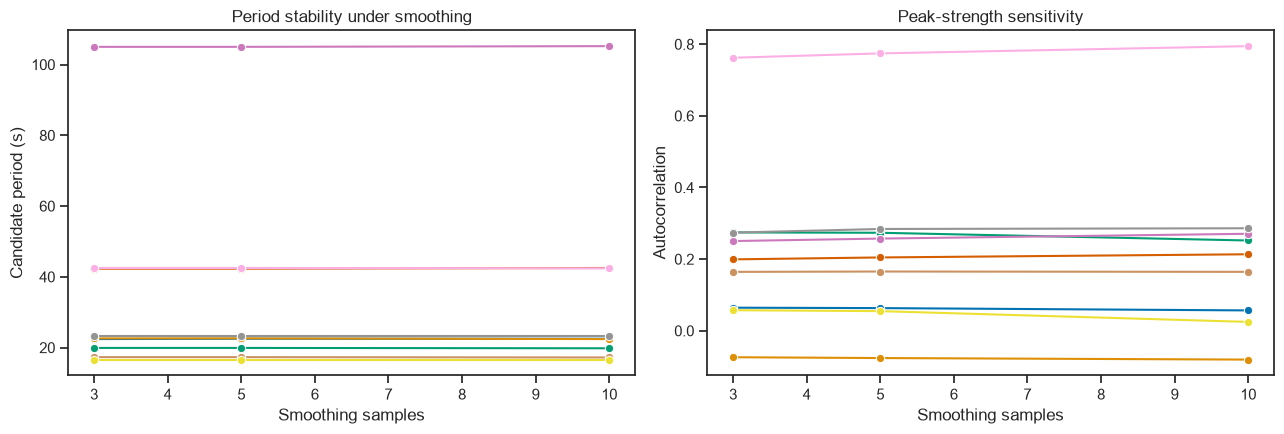

In [8]:
if len(smoothing):
    smoothing_plot = smoothing.assign(recording=smoothing["recording_id"].str[:8])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.lineplot(data=smoothing_plot, x="smooth_samples", y="lag_s", hue="recording", marker="o", legend=False, ax=axes[0])
    axes[0].set(title="Period stability under smoothing", xlabel="Smoothing samples", ylabel="Candidate period (s)")
    sns.lineplot(data=smoothing_plot, x="smooth_samples", y="correlation", hue="recording", marker="o", legend=False, ax=axes[1])
    axes[1].set(title="Peak-strength sensitivity", xlabel="Smoothing samples", ylabel="Autocorrelation")
    fig.tight_layout()

## Controlled interpolation sensitivity

Observed timestamps are already regular. Samples are deliberately hidden, then reconstructed from elapsed time. This tests gap sensitivity; it does not recover new timing information.

Text(0.5, 1.03, 'drive_day_2026: interpolation sensitivity')

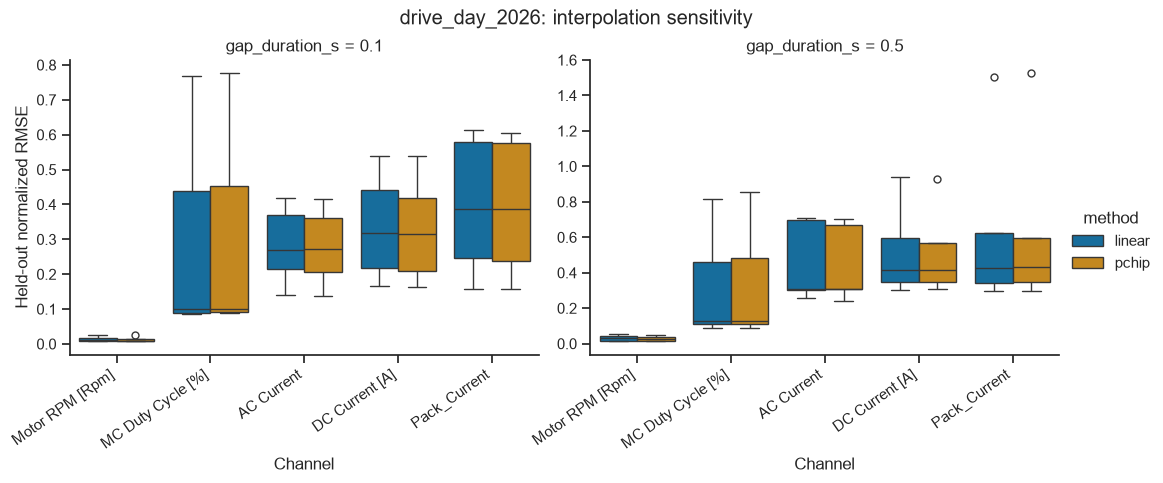

In [9]:
benchmark_rows = []
benchmark_records = pd.concat([manifest.nlargest(6, "duration_s"), manifest.loc[manifest["control_candidate"]].nlargest(2, "duration_s")]).drop_duplicates("recording_id")
long_gap_samples = max(2, round(dataset.native_sample_rate_hz * 0.5))
for record in benchmark_records.itertuples(index=False):
    frame = load_recording(record.primary_path, dataset)
    channels = select_informative_channels(frame, dataset.analysis_channels)
    benchmark = benchmark_interpolation(frame, channels, gap_samples=(1, long_gap_samples))
    benchmark["recording_id"] = record.recording_id
    benchmark["motion_status"] = record.motion_status
    benchmark_rows.append(benchmark)
interpolation = pd.concat(benchmark_rows, ignore_index=True)
interpolation["gap_duration_s"] = interpolation["gap_samples"] / dataset.native_sample_rate_hz
interpolation.to_csv(result.output_dir / "interpolation_benchmark.csv", index=False)
grid = sns.catplot(data=interpolation, x="channel", y="normalized_rmse", hue="method", col="gap_duration_s", kind="box", sharey=False, height=4.0, aspect=1.35)
grid.set_xticklabels(rotation=35, ha="right")
grid.set_axis_labels("Channel", "Held-out normalized RMSE")
grid.figure.suptitle(f"{DATASET_KEY}: interpolation sensitivity", y=1.03)

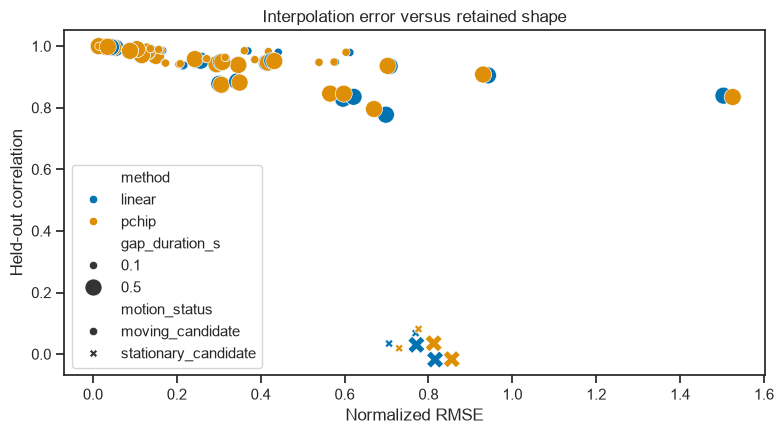

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(data=interpolation, x="normalized_rmse", y="correlation", hue="method", style="motion_status", size="gap_duration_s", sizes=(35, 150), ax=ax)
ax.set(title="Interpolation error versus retained shape", xlabel="Normalized RMSE", ylabel="Held-out correlation")
fig.tight_layout()

## Physically interpretable cumulative proxies

Text(0.5, 1.02, 'drive_day_2026: integrated sensor proxies, recording 667a6e15')

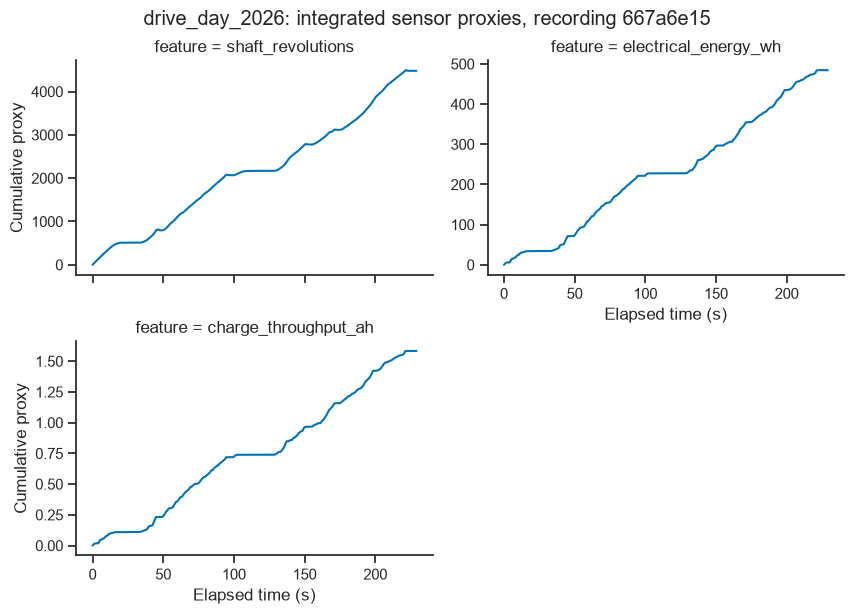

In [11]:
example = manifest.loc[~manifest["control_candidate"]].nlargest(1, "duration_s").iloc[0]
example_frame = load_recording(example["primary_path"], dataset)
integrated = build_integrated_features(example_frame, DATASET_KEY)
integrated.to_csv(result.output_dir / "integrated_features_example.csv", index=False)
integrated_long = integrated.melt(id_vars="elapsed_s", var_name="feature", value_name="value")
grid = sns.relplot(data=integrated_long, x="elapsed_s", y="value", col="feature", col_wrap=2, kind="line", height=3.0, aspect=1.45, facet_kws={"sharey": False})
grid.set_axis_labels("Elapsed time (s)", "Cumulative proxy")
grid.figure.suptitle(f"{DATASET_KEY}: integrated sensor proxies, recording {example['recording_id'][:8]}", y=1.02)

In [12]:
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
run_manifest["data_provenance"]

{'dataset_key': 'drive_day_2026',
 'native_sample_rate_hz': 10.0,
 'clock_provenance': 'recorded_time_column',
 'selected_channels': ['Motor RPM [Rpm]',
  'MC Duty Cycle [%]',
  'AC Current',
  'DC Current [A]',
  'Pack_Current'],
 'semantic_mapping': {'Motor RPM [Rpm]': 'motor_rpm',
  'MC Duty Cycle [%]': 'motor_controller_duty_pct',
  'AC Current': 'motor_ac_current',
  'DC Current [A]': 'motor_dc_current_a',
  'Pack_Current': 'pack_current'},
 'semantic_mapping_version': '1.0',
 'motion_policy': 'motor_rpm_threshold'}

## Interpretation boundary

Positive recurrence means measured behavior repeats. It does not prove laps, locate a start line, identify a driver, or establish accuracy. Integrated RPM gives shaft revolutions, not distance. Electrical integration is an energy proxy. Yaw and acceleration integrals drift and provide only bounded relative-motion proxies.